In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [2]:
# promeni ime fajla ako je drugačije
df = pd.read_excel("ANFIS.xlsx")

# koristimo samo ulaze i izlaz
X = df[["Coop", "Adap", "Forg", "Stoch"]].values
y = df["Output"].values.reshape(-1,1)

# ============================
# 2. NORMALIZACIJA
# ============================

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

Xn = scaler_X.fit_transform(X)
yn = scaler_y.fit_transform(y)

# ============================
# 3. PODELA NA TRAIN/TEST
# ============================

X_train, X_test, y_train, y_test = train_test_split(Xn, yn, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)
y_test  = torch.tensor(y_test, dtype=torch.float32)

# ============================
# 4. DEFINICIJA ANFIS MODEL
# ============================

class GaussianMF(nn.Module):
    def __init__(self, c, sigma):
        super().__init__()
        self.c = nn.Parameter(torch.tensor(float(c)))
        self.sigma = nn.Parameter(torch.tensor(float(sigma)))
    def forward(self, x):
        return torch.exp(-0.5 * ((x - self.c) / self.sigma)**2)

class ANFIS(nn.Module):
    def __init__(self, n_inputs, mfs_per_input):
        super().__init__()
        self.n_inputs = n_inputs
        self.m = mfs_per_input
        
        # membership functions: list of list of GaussianMF
        self.mf_layer = nn.ModuleList([
            nn.ModuleList([GaussianMF(0.5, 0.2) for _ in range(mfs_per_input)])
            for _ in range(n_inputs)
        ])
        
        # number of rules
        self.n_rules = mfs_per_input ** n_inputs
        
        # Sugeno linear consequents
        self.linear = nn.Linear(n_inputs, self.n_rules, bias=True)

    def forward(self, x):
        batch_size = x.size(0)

        # membership shape: [batch, input, mf]
        memberships = torch.stack([
            torch.stack([mf(x[:, i]) for mf in self.mf_layer[i]], dim=-1)
            for i in range(self.n_inputs)
        ], dim=1)

        # rule strength = product of membership values
        rule_strengths = memberships[:,0,:]
        for i in range(1, self.n_inputs):
            rule_strengths = rule_strengths.unsqueeze(2) * memberships[:,i,:].unsqueeze(1)
            rule_strengths = rule_strengths.reshape(batch_size, -1)

        w_normalized = rule_strengths / (rule_strengths.sum(dim=1, keepdim=True) + 1e-6)

        linear_output = self.linear(x)  # [batch, n_rules]
        output = (w_normalized * linear_output).sum(dim=1, keepdim=True)
        return output

In [3]:
n_inputs = 4
mfs_per_input = 3

model = ANFIS(n_inputs=n_inputs, mfs_per_input=mfs_per_input)
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

epochs = 200
batch_size = 512

loss_history = []

for epoch in range(epochs):
    perm = torch.randperm(X_train.size(0))
    epoch_loss = 0
    for i in range(0, X_train.size(0), batch_size):
        idx = perm[i:i+batch_size]
        xb = X_train[idx]
        yb = y_train[idx]

        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * xb.size(0)

    epoch_loss /= X_train.size(0)
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.6f}")

Epoch 1/200, Loss: 0.398402
Epoch 2/200, Loss: 0.215047
Epoch 3/200, Loss: 0.143413
Epoch 4/200, Loss: 0.110820
Epoch 5/200, Loss: 0.095367
Epoch 6/200, Loss: 0.081667
Epoch 7/200, Loss: 0.072677
Epoch 8/200, Loss: 0.068464
Epoch 9/200, Loss: 0.065302
Epoch 10/200, Loss: 0.062788
Epoch 11/200, Loss: 0.060812
Epoch 12/200, Loss: 0.059212
Epoch 13/200, Loss: 0.057882
Epoch 14/200, Loss: 0.056762
Epoch 15/200, Loss: 0.055873
Epoch 16/200, Loss: 0.055119
Epoch 17/200, Loss: 0.054382
Epoch 18/200, Loss: 0.053803
Epoch 19/200, Loss: 0.053289
Epoch 20/200, Loss: 0.052862
Epoch 21/200, Loss: 0.052501
Epoch 22/200, Loss: 0.052047
Epoch 23/200, Loss: 0.051720
Epoch 24/200, Loss: 0.051299
Epoch 25/200, Loss: 0.050952
Epoch 26/200, Loss: 0.050634
Epoch 27/200, Loss: 0.050400
Epoch 28/200, Loss: 0.050069
Epoch 29/200, Loss: 0.049791
Epoch 30/200, Loss: 0.049566
Epoch 31/200, Loss: 0.049297
Epoch 32/200, Loss: 0.049217
Epoch 33/200, Loss: 0.048904
Epoch 34/200, Loss: 0.048672
Epoch 35/200, Loss: 0.0

RMSE na test setu: 0.12531122159281058


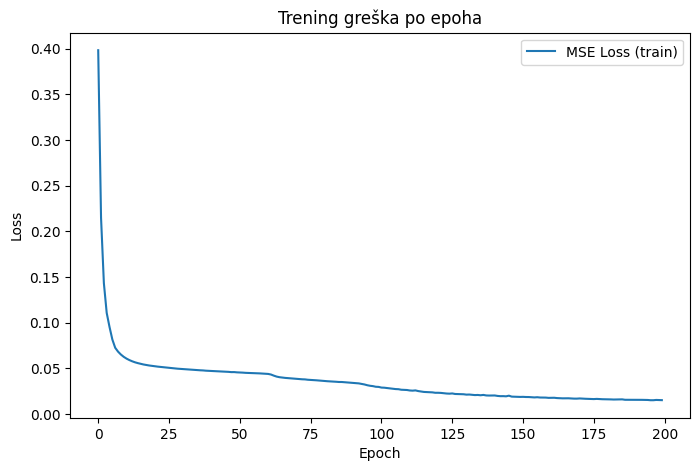

In [4]:
with torch.no_grad():
    y_pred = model(X_test).numpy()

y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_test_rescaled = scaler_y.inverse_transform(y_test)

rmse = np.sqrt(np.mean((y_test_rescaled - y_pred_rescaled)**2))
print("RMSE na test setu:", rmse)

# ============================
# 7. GRAFIK GREŠKE
# ============================

plt.figure(figsize=(8,5))
plt.plot(loss_history, label="MSE Loss (train)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Trening greška po epoha")
plt.legend()
plt.show()

In [5]:
import joblib  # za čuvanje skalera

torch.save(model.state_dict(), "anfis_model.pt")
joblib.dump(scaler_X, "scaler_X.save")
joblib.dump(scaler_y, "scaler_y.save")


['scaler_y.save']